In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torchvision import models
import torchvision.models as models
import torch.nn as nn
import matplotlib.ticker as ticker

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ToTensor：画像のグレースケール化（RGBの0~255を0~1の範囲に正規化）、Normalize：Z値化（RGBの平均と標準偏差を0.5で決め打ちして正規化）
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

BATCH_SIZE = 1024
LEARNING_RATE = 0.01
EPOCHS = 200

#データをダウンロード
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=5)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, num_workers=5)

In [24]:
#SGD
model = models.resnet18(weights=None)

# CIFAR用に変更
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

SGD_train_loss_x = []
SGD_train_loss = []
N = len(trainloader.dataset)
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch:{epoch + 1}")
    model.train()
    train_loss = 0
    for X, Y in tqdm(trainloader):
        X, Y = X.to(device), Y.to(device)

        outputs = model(X)
        loss = criterion(outputs, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    fg_count += 1
    SGD_train_loss_x.append(fg_count)
    SGD_train_loss.append(train_loss / len(trainloader))
    print(f"Loss: {train_loss / len(trainloader):.6f}")

    if fg_count >= 200:
        break

epoch:1


100%|██████████| 98/98 [00:23<00:00,  4.17it/s]


Loss: 2.287549
epoch:2


100%|██████████| 98/98 [00:22<00:00,  4.31it/s]


Loss: 2.222518
epoch:3


...

Loss: 0.618550
epoch:199


100%|██████████| 98/98 [00:21<00:00,  4.59it/s]


Loss: 0.612185
epoch:200


100%|██████████| 98/98 [00:21<00:00,  4.59it/s]

Loss: 0.605900


In [25]:
#SVRG
class SVRG_SGD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # full_grad，prev_pを初期化
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['prev_p'] = torch.clone(p) # prev_pの初期値はパラメータ

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)

    def culc_prev_grads(self, model, X, T, loss_func):
        # prev_pに切り替え
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"]) # パラメータをprev_vに変換

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_vに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                z = state['z']
                prev_grad = state["prev_grad"]
                # 補正勾配を更新
                v = grad - prev_grad + z

                # パラメータを更新
                p.sub_(v, alpha = lr)

        return loss


model = models.resnet18(weights=None)
# CIFAR用に変更
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = SVRG_SGD(model.parameters(), lr = LEARNING_RATE)

SVRG_train_loss_x = []
SVRG_train_loss = []
N = len(trainloader.dataset)
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.calc_full_grads(model, trainloader, criterion)
    fg_count += 1

    for X, Y in tqdm(trainloader):
        X, Y = X.to(device), Y.to(device)

        optimizer.culc_prev_grads(model, X, Y, criterion)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    fg_count += 2
    SVRG_train_loss_x.append(fg_count)
    SVRG_train_loss.append(train_loss / len(trainloader))
    print(f"Loss: {train_loss / len(trainloader):.6f}")

    if fg_count >= 200:
        break    

epoch; 1


100%|██████████| 98/98 [00:41<00:00,  2.34it/s]

Loss: 2.318690
epoch; 2



100%|██████████| 98/98 [00:41<00:00,  2.35it/s]

Loss: 2.243005
epoch; 3


...

Loss: 1.312376
epoch; 66



100%|██████████| 98/98 [00:44<00:00,  2.19it/s]

Loss: 1.305850
epoch; 67



100%|██████████| 98/98 [00:43<00:00,  2.23it/s]

Loss: 1.299061


In [61]:
#NFG_SVRG
class NFG_SVRG_SGD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())     

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss


model = models.resnet18(weights=None)
# CIFAR用に変更
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG_SGD(model.parameters(), lr = LEARNING_RATE)

NFG_train_loss_x = []
NFG_train_loss = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.init_epoch()

    for X, Y in tqdm(trainloader):
        X, Y = X.to(device), Y.to(device)

        optimizer.culc_prev_grads(model, X, Y, criterion)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    fg_count += 2

    NFG_train_loss_x.append(fg_count)
    NFG_train_loss.append(train_loss / len(trainloader))
    print(f"Loss: {train_loss / len(trainloader):.6f}")

    if fg_count >= 200:
        break

epoch; 1


100%|██████████| 49/49 [00:44<00:00,  1.10it/s]


Loss: 2.404994
epoch; 2


100%|██████████| 49/49 [00:44<00:00,  1.11it/s]


Loss: 2.199772
epoch; 3


...

Loss: 0.190555
epoch; 99


100%|██████████| 49/49 [00:41<00:00,  1.17it/s]


Loss: 0.169463
epoch; 100


100%|██████████| 49/49 [00:42<00:00,  1.17it/s]

Loss: 0.155141


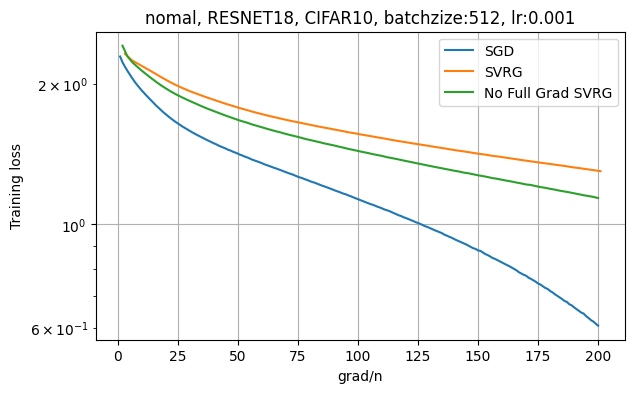

In [32]:
fig = plt.figure(figsize = (15, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(SGD_train_loss_x, SGD_train_loss, label = "SGD")
ax.plot(SVRG_train_loss_x, SVRG_train_loss, label = "SVRG")
ax.plot(NFG_train_loss_x, NFG_train_loss, label = "No Full Grad SVRG")
ax.set_xlabel("grad/n")
ax.set_ylabel("Training loss")
ax.set_yscale('log')
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))
ax.set_title("nomal, RESNET18, CIFAR10, batchzize:512, lr:0.001")
ax.grid()
ax.legend()

batchsize: 1024
lr: 0.01 固定
EPOCHS: 200


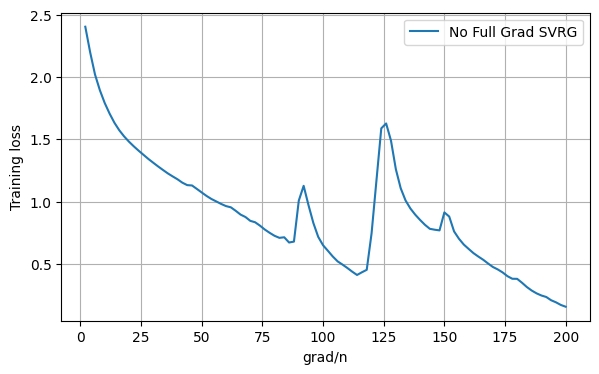

In [62]:
print('batchsize:', BATCH_SIZE)
print('lr:', LEARNING_RATE, '固定')
print('EPOCHS:', EPOCHS)

fig = plt.figure(figsize = (15, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(NFG_train_loss_x, NFG_train_loss, label = "No Full Grad SVRG")
ax.set_xlabel("grad/n")
ax.set_ylabel("Training loss")
ax.grid()
ax.legend()